In [ ]:
# HyperTools setup: use 1.1 or newer; retain a current local checkout.
import importlib.util
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version
from pathlib import Path
try:
    _hypertools_version = Version(version('hypertools'))
except PackageNotFoundError:
    _hypertools_version = Version('0')
if _hypertools_version < Version('1.1.0'):
    _spec = importlib.util.find_spec('hypertools')
    if _spec and _spec.origin and (Path(_spec.origin).resolve().parents[1] / '.git').exists():
        raise RuntimeError('Select a HyperTools 1.1 checkout/kernel before running this tutorial; the installer will not replace your checkout.')
    %pip install -q "hypertools[interactive]>=1.1.0"
else:
    print('Keeping HyperTools', _hypertools_version, 'in this kernel. Optional extras are loaded when requested.')


# Loading and saving data with `hyp.load` and `hyp.save`

`hyp.load` takes a string and works out what it names, trying in order: a hosted example dataset, a scikit-learn bundled dataset, a seaborn dataset, a FiveThirtyEight or Kaggle prefix, a built-in synthetic dataset, an explicit web-source prefix (`'wikipedia:'`/`'yahoo:'`/`'sec:'`), a local file, a Hugging Face dataset id, a Google Sheets, Drive or Dropbox link, and finally any URL. `hyp.save` writes in the format its file extension names, and everything it writes loads back. `hyp.plot(..., save_path=)` does the same for figures and animations. This notebook exercises each route on small data, writing its scratch files to a temporary directory it removes at the end.

## Import packages

In [1]:
import os
import shutil
import tempfile

import numpy as np
import pandas as pd

import hypertools as hyp

%matplotlib inline
workdir = tempfile.mkdtemp(prefix='hypertools_io_')

## Hosted example datasets

The built-in names (`weights`, `weights_sample`, `spiral`, `mushrooms`, `wiki`, `nips`, `sotus`, the shapes zoo, `datasaurus`, ...) are downloaded once into `~/hypertools_data` and read from there afterwards. `weights_sample` is a list of three arrays; `spiral` is a list of two 3-D curves.

weights_sample: list [(300, 100), (300, 100), (300, 100)]
spiral:         list [(1000, 3), (1000, 3)]


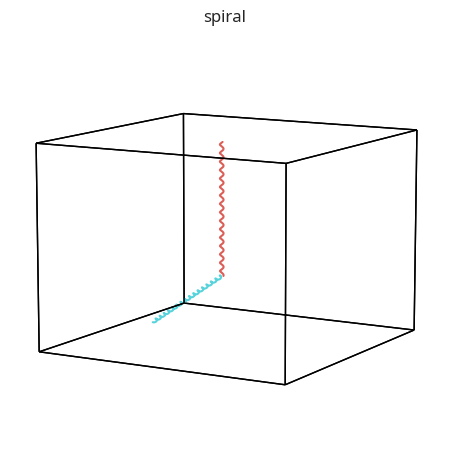

In [2]:
subjects = hyp.load('weights_sample')
spiral = hyp.load('spiral')
print('weights_sample:', type(subjects).__name__, [s.shape for s in subjects])
print('spiral:        ', type(spiral).__name__, [s.shape for s in spiral])
fig = hyp.plot(spiral, title='spiral')

## Synthetic datasets

`hyp.load` can also *generate* data on the spot -- nothing is downloaded, and the result is fully reproducible from `random_state=`. The registered names (`random_walk`, `helix`, `lorenz`, `blobs`, `moons`, `swiss_roll`, `s_curve`) and their keyword arguments live in `hyp.io.sources.SYNTHETIC_DATASETS`; `synthetic_dataset_docs()` renders that registry as a doc list. Passing `n_datasets=` turns any of them into a *list* of independently seeded datasets -- the same shape `hyp.load('weights')` returns.

random_walk: list [(200, 3), (200, 3), (200, 3)]


    * ``random_walk`` -- Gaussian random walk: (n_samples, n_features) array, cumulative sum of normal steps. kwargs: n_samples=300, n_features=10, step=1.0, drift=0.0
    * ``helix`` -- 3D helix: (n_samples, 3) array. kwargs: n_samples=300, turns=3.0, noise=0.0, radius=1.0, pitch=1.0
    * ``lorenz`` -- Lorenz attractor trajectory (fixed-step RK4): (n_samples, 3) array. kwargs: n_samples=2000, sigma=10.0, rho=28.0, beta=8/3, dt=0.01, x0=None
    * ``blobs`` -- isotropic Gaussian blobs via sklearn.datasets.make_blobs: DataFrame of dim_* columns + a 'target' cluster label. Its kwargs (n_samples, n_features, centers, cluster_std, ...) pass straight through
    * ``moons`` -- two interleaving half-circles via sklearn.datasets.make_moons: DataFrame of dim_0/dim_1 + a 'target' label. Its kwargs (n_samples, noise, ...) pass straight through
    * ``swiss_roll`` -- Swiss-roll manifold via sklearn.datasets.make_swiss_roll: DataFrame of dim_0/1/2 + 't', the position along the roll. Its kwargs (

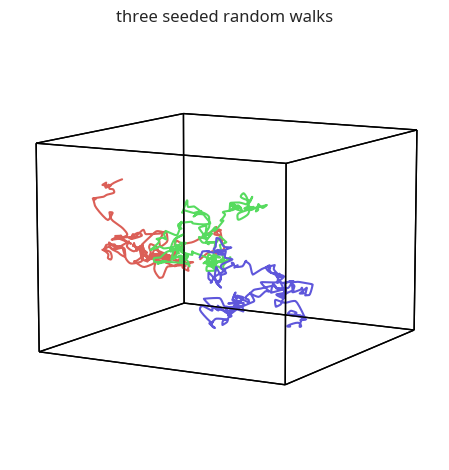

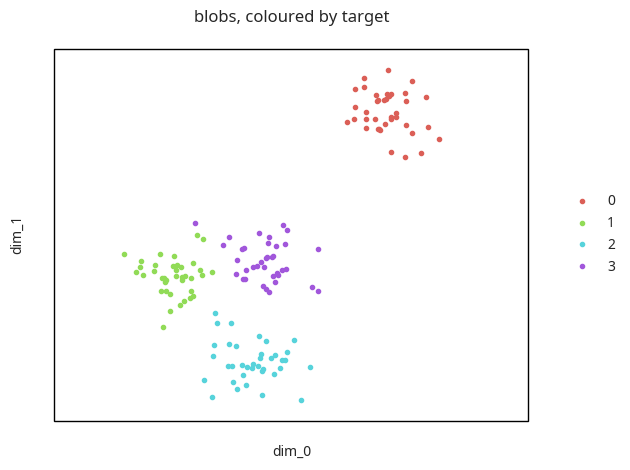

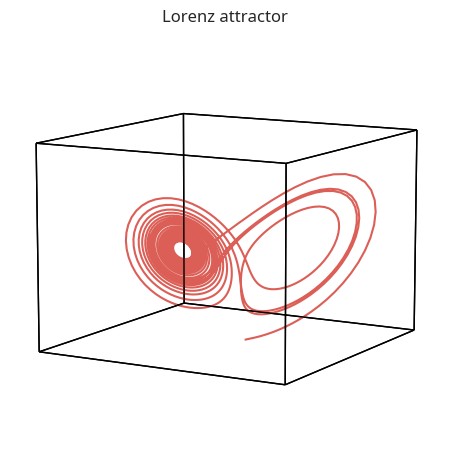

In [3]:
walks = hyp.load('random_walk', n_datasets=3, n_samples=200, n_features=3, random_state=42)
print('random_walk:', type(walks).__name__, [w.shape for w in walks])
fig = hyp.plot(walks, title='three seeded random walks')

clusters = hyp.load('blobs', n_samples=150, centers=4, random_state=1)
fig = hyp.plot(clusters.drop(columns='target'), '.', hue=clusters['target'], legend=True,
               title='blobs, coloured by target')

lorenz = hyp.load('lorenz', n_samples=2000, random_state=0)
fig = hyp.plot(lorenz, title='Lorenz attractor')

print(hyp.io.sources.synthetic_dataset_docs())

## scikit-learn's bundled datasets

`'iris'`, `'digits'`, `'wine'`, `'breast_cancer'`, `'diabetes'` and `'linnerud'` resolve to the corresponding `sklearn.datasets.load_*` function and come back as a DataFrame of the features with the target appended as a `target` column. (A hosted example name always wins over a same-named scikit-learn or seaborn dataset, and scikit-learn wins over seaborn.)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


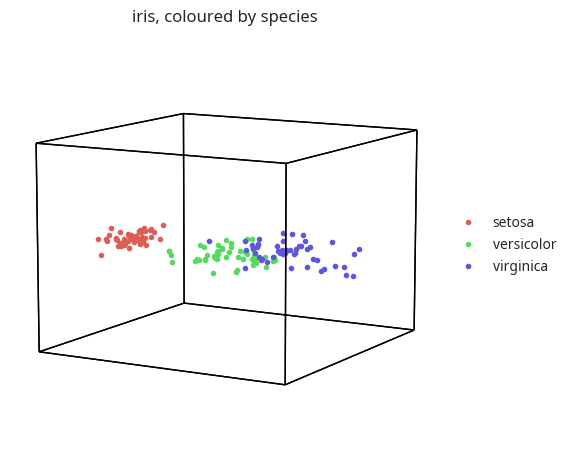

In [4]:
iris = hyp.load('iris')
species = ['setosa', 'versicolor', 'virginica']
fig = hyp.plot(iris.drop(columns='target'), '.', hue=[species[t] for t in iris['target']],
               legend=True, title='iris, coloured by species')
iris.head()

## Local files: `hyp.save` round trips

`hyp.save(obj, path)` picks the format from the extension: `.csv`/`.tsv`/`.txt` are delimited text, `.npy` a numpy array, `.npz` an archive with one array per list element (or per dict key), `.json` and `.parquet` and `.xlsx` are DataFrame formats, `.mat` a MATLAB file, and anything else -- `.pkl` included -- a pickle. Writes are atomic, so a failed save never destroys the file already at that path. `hyp.load` reads every one of them back; Reading and writing `.xlsx` need the `io` extra (openpyxl), which is installed on first use.

In [5]:
table = iris.drop(columns='target')
saved = {}
for ext in ('csv', 'tsv', 'npy', 'npz', 'json', 'parquet', 'mat', 'xlsx', 'pkl'):
    path = os.path.join(workdir, f'iris.{ext}')
    obj = table.to_numpy() if ext == 'npy' else subjects if ext == 'npz' else table
    hyp.save(obj, path)
    back = hyp.load(path)
    same = (all(np.allclose(a, b) for a, b in zip(obj, back)) if ext == 'npz'
            else np.allclose(np.asarray(obj), np.asarray(back)))
    saved[ext] = (type(back).__name__, os.path.getsize(path), same)
pd.DataFrame(saved, index=['loads back as', 'bytes', 'values identical']).T

,loads back as,bytes,values identical
csv,DataFrame,2470,True
tsv,DataFrame,2470,True
npy,ndarray,4928,True
npz,list,360748,True
json,DataFrame,5647,True
parquet,DataFrame,4613,True
mat,ndarray,4984,True
xlsx,DataFrame,7726,True
pkl,DataFrame,5715,True


## A URL

Any `http(s)` URL is fetched and parsed by its extension (or by content when it has none). This one is the city table the weather tutorial uses. Data formats such as `.csv` never need `trust=`; only pickles, which can execute code, do.

In [6]:
url = ('https://raw.githubusercontent.com/ContextLab/hypertools-paper-notebooks/'
       'master/data/temperature_locs.csv')
cities = hyp.load(url, cache=True)
print(cities.shape)

# offline=True reads ONLY from that on-disk cache -- no connection is opened
cities_offline = hyp.load(url, offline=True)
print('offline read matches:', (cities_offline.values == cities.values).all())

# a URL that was never cached raises HypertoolsOfflineError under offline=True
uncached_url = url.replace('temperature_locs.csv', 'not_a_real_file.csv')
try:
    hyp.load(uncached_url, offline=True)
except hyp.io.sources.HypertoolsOfflineError as error:
    print(str(error)[:120], '...')

cities.head()

(20, 4)
offline read matches: True
offline=True, but https://raw.githubusercontent.com/ContextLab/hypertools-paper-notebooks/master/data/not_a_real_file.cs ...


,Unnamed: 0,City,Lat,Long
0,0,Bangkok,13.66,99.91
1,0,Bombay,18.48,72.68
2,0,Cairo,29.74,31.38
3,0,Cape_Town,-32.95,18.19
4,0,Chicago,42.59,-87.27


## Web sources

Three more prefixes fetch data live from the web: `'wikipedia:<Title>'` (plain-text article extract), `'yahoo:<TICKER>'` (daily price history from Yahoo Finance, with explicit `start=`/`end=` bounds), and `'sec:<TICKER>'` (one XBRL concept's reported values, from the SEC's company-facts API). All three are explicit prefixes -- a name starting with one of them is never mistaken for anything else.

In [7]:
article = hyp.load('wikipedia:Dimensionality reduction')
print(len(article), repr(article[:100]))

aapl = hyp.load('yahoo:AAPL', start='2024-01-01', end='2024-03-01')
print(aapl.shape, aapl.index.min().date(), '->', aapl.index.max().date())

ko = hyp.load('sec:KO', concept='Revenues')
print(ko.shape)

9658 'Dimensionality reduction, or dimension reduction, is the transformation of data from a high-dimensio'


(41, 6) 2024-01-02 -> 2024-02-29


(36, 9)


## A Hugging Face dataset, streamed

A Hugging Face dataset id loads through the `datasets` library (the `text` extra, installed on first use). With `streaming=True` it comes back as an `IterableDataset`, which `hyp.plot` consumes chunk by chunk: `stream_init` samples fix the display box, then each `stream_chunk` is projected into it. Iris on the Hub is sorted by species, so the stream is shuffled first -- otherwise the first fifty samples would all be one species and the rest would land outside the box they fitted. `select_columns` keeps the four measurements.

IterableDataset
150 samples streamed


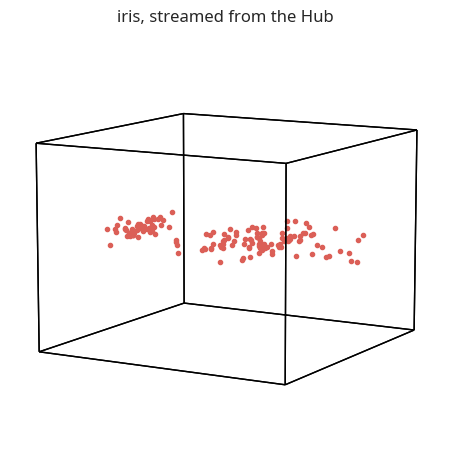

In [8]:
stream = hyp.load('scikit-learn/iris', streaming=True)
print(type(stream).__name__)
stream = stream.select_columns(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
fig = hyp.plot(stream.shuffle(seed=0, buffer_size=150), '.', stream_init=50, stream_chunk=25,
               title='iris, streamed from the Hub')
print(fig.stream_info['n_samples'], 'samples streamed')
fig

## Data you already hold passes straight through

`hyp.load` is mainly for *names*: strings, paths and URLs. A DataFrame, a numpy array, or a list of those is returned unchanged, with the same `reduce=`/`ndims=`/`align=`/`normalize=` post-processing loaded data gets, so one `hyp.load` call can serve as the entry point over a mixed list of names and in-memory data. Anything else (a dict, a number) is still a `TypeError` that says what is accepted.


True the frame comes back as the same object
2 datasets: the in-memory array and the hosted spiral
hypertools.load: dataset must be a string (a dataset name, file path, or URL), a path-like object, an already-loaded pandas DataFrame or numpy array, or a list/tuple of those; got dict


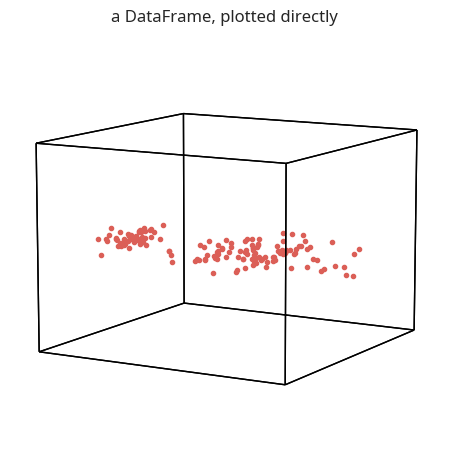

In [9]:
same = hyp.load(table)
print(same is table, 'the frame comes back as the same object')
mixed = hyp.load([table.to_numpy(), 'spiral'])
print(len(mixed), 'datasets: the in-memory array and the hosted spiral')
try:
    hyp.load({'not': 'data'})
except TypeError as error:
    print(error)
fig = hyp.plot(table, '.', title='a DataFrame, plotted directly')


## Saving figures and animations with `save_path=`

`hyp.plot(..., save_path=)` writes the figure in the format the extension names -- any `matplotlib.pyplot.savefig` format for a static plot -- and the plotly backend writes `.html`. For an animation, `.gif`, `.png`/`.apng` and `.svg` need nothing extra; the video formats (`.mp4`, `.mov`, ...) need FFmpeg on the machine. Every frame is rendered and encoded, so pass a short `duration=` for a quick export. The animation below is saved next to this notebook as `io.mp4` and its last frame is shown in place; the still images go to the scratch directory.

In [10]:
fig = hyp.plot(table, '.', save_path=os.path.join(workdir, 'iris.png'), show=False)
fig = hyp.plot(table, '.', save_path=os.path.join(workdir, 'iris.pdf'), show=False)
with hyp.set_interactive_backend('plotly'):
    fig = hyp.plot(table, '.', save_path=os.path.join(workdir, 'iris.html'), show=False)
for name in ('iris.png', 'iris.pdf', 'iris.html'):
    print(f'{name}: {os.path.getsize(os.path.join(workdir, name)):,} bytes')
anim = hyp.plot(subjects, animate=True, duration=4, frame_rate=15, save_path='io.mp4',
                title='three subjects, saved as io.mp4', show=False)
print(f'io.mp4: {anim.n_frames} frames, {os.path.getsize("io.mp4"):,} bytes')
_ = anim.draw_frame(anim.n_frames - 1)
anim.figure

# Colab serves output frames separately from kernel files; embed movie bytes.
try:
    from google import colab as colab
except ImportError:
    pass  # Local Jupyter/Sphinx uses the relative video below.
else:
    from IPython.display import Video, display
    display(Video('io.mp4', embed=True))


iris.png: 20,507 bytes
iris.pdf: 4,270 bytes
iris.html: 4,859,414 bytes


io.mp4: 60 frames, 339,451 bytes


<video controls loop muted autoplay playsinline src="io.mp4" title="Three subjects, saved with save_path=" style="max-width: 100%"></video>

[Download the clip](io.mp4)

## When loading or saving fails: `HypertoolsIOError`

A name that resolves to nothing, an unreadable file, or a target the save cannot write raises `hyp.HypertoolsIOError`, so I/O failures can be caught separately from everything else.

In [11]:
attempts = [('load a file that does not exist', lambda: hyp.load(os.path.join(workdir, 'missing.csv'))),
            ('save into a directory that does not exist', lambda: hyp.save(table, os.path.join(workdir, 'no_such_dir', 'iris.csv')))]
for label, call in attempts:
    try:
        call()
    except hyp.HypertoolsIOError as error:
        print(f'{label}:\n    HypertoolsIOError: {str(error).replace(workdir, "<workdir>")[:110]}...\n')

load a file that does not exist:
    HypertoolsIOError: could not load '<workdir>/missing.csv'. Tried, in order:
  - built-in example dataset: not one of ['biplane', ...

save into a directory that does not exist:
    HypertoolsIOError: cannot save to <workdir>/no_such_dir/iris.csv: the parent directory <workdir>/no_such_dir does not exist. Crea...



## Clean up

In [12]:
shutil.rmtree(workdir)